In [1]:
#  evaluate the interpreter translation steps.  It appears that my interpreters 
#   are too wishy washy. I need some zeros and ones!  


#  What I would do is build a landscape_stack.py and then do some plotting



In [11]:
# set up the config values

landscape_stack_config = {
    "id_prefix": "DL",
    "id_strategy": "hash",   # or "uuid"
    "explicit_id": None,     # set to a string if you want to force an ID

    # --- Base disturbance landscape setup ---
    "tif_path": "downloaded_images/snic_10_2019_-12.004_132.979.tif",  # <-- change to your SNIC patch raster

    "disturbance_config": {
        "random": {
            "seed": None,    # or an int for reproducibility
        },
        "raster": {
            "band": 1,
        },
        "types": {
            "type1": {
                "name": "Conifer",
                "proportion_of_patches": 0.6,
                "initial_cover": {
                    "target_mean": 0.90,   # in (0,1)
                    "kappa": 20.0,
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.02,
                        "background_alpha": 0.3,
                        "background_beta": 8.0,
                        "catastrophic_alpha": 8.0,
                        "catastrophic_beta": 0.7,
                    }
                },
            },
            "type2": {
                "name": "Broadleaf",
                "proportion_of_patches": 0.4,
                "initial_cover": {
                    "target_mean": 0.85,
                    "kappa": 18.0,
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.05,
                        "background_alpha": 0.4,
                        "background_beta": 7.0,
                        "catastrophic_alpha": 7.0,
                        "catastrophic_beta": 0.8,
                    }
                },
            },
        },
        "thresholds": {
            "final_cover_percent": 15.0,
        },
        "simulation": {
            "max_retries": 10,
        },
        # Optional plotting defaults (you can ignore or tweak later)
        "plotting": {
            "type_cmap": "tab10",
            "initial_cover_cmap": "Greens",
            "proportional_loss_cmap": "Oranges",
            "loss_abs_cmap": "Reds",
            "final_cover_cmap": "Blues",
            "disturbed_cmap": "Greys_r",
        },
    },

    # --- Sensor configurations (arbitrary number of sensors) ---
    "sensors": [
        {
            "name": "Landsat_OLI",
            "config": {
                "signal_transform": {
                    "max_signal": 1000.0,
                    "curve_k": 3.0,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.02,
                },
                "types": {
                    # override type-specific behavior if desired
                    "type1": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.03,
                        }
                    },
                    "type2": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.01,
                        }
                    },
                },
                "lowpass_filter": {
                    "kernel_size": 3,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 10.0,
                    "amplitude_proportion_of_range": 0.10,
                },
            },
        },

        {
            "name": "Sentinel2_MSI",
            "config": {
                "signal_transform": {
                    "max_signal": 1500.0,
                    "curve_k": 2.5,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.015,
                },
                "lowpass_filter": {
                    "kernel_size": 5,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 15.0,
                    "amplitude_proportion_of_range": 0.12,
                },
            },
        },
    ],

    # --- Interpreter configuration (single interpreter) ---
    "interpreter": {
        "name": "DefaultInterpreter",
        "config": {
            "detection_curve": {
                "pivot_loss": 15.0,
                "slope": 0.3,
            },
            "definition_curve": {
                "slope": 0.4,
                "threshold_override": None,  # use DisturbanceLandscape threshold by default
            },
            "gaussian_patch_noise": {
                "std_dev_percent": 1.0,
            },
            "beta_patch_uncertainty": {
                "alpha": 0.1,
                "beta": 12.0,
            },
            "lowpass_filter": {
                "kernel_size": 3,
            },
            "spatial_uncertainty": {
                "spatial_autocorr_distance": 8.0,
                "max_scaler": 0.01,
            },
        },
    },
}

train_experiment_config = {
    "n_stacks": 1,
    "disturbance_seed_base": 10_000,
    "use_separate_seeds_per_stack": True,

    "patch_dir": "downloaded_images/",
    "patch_selection_seed": 123,

    "sensor_name_for_strat": "Landsat_OLI",
    "n_strata": 5,
    "samples_per_stratum": 50,
    "sampling_seed": 42,
}

In [12]:
import landscape_stack_collection 
import importlib 
importlib.reload(landscape_stack_collection)
from landscape_stack_collection import LandscapeStackCollection


from disturbance_helper_functions import flatten_config, generate_run_id, _append_to_master_log, export_with_metadata


train_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=landscape_stack_config,
    experiment_cfg=train_experiment_config,
)






{'Landsat_OLI': <sensor_field.SensorField object at 0x176db9190>, 'Sentinel2_MSI': <sensor_field.SensorField object at 0x176db9a90>}


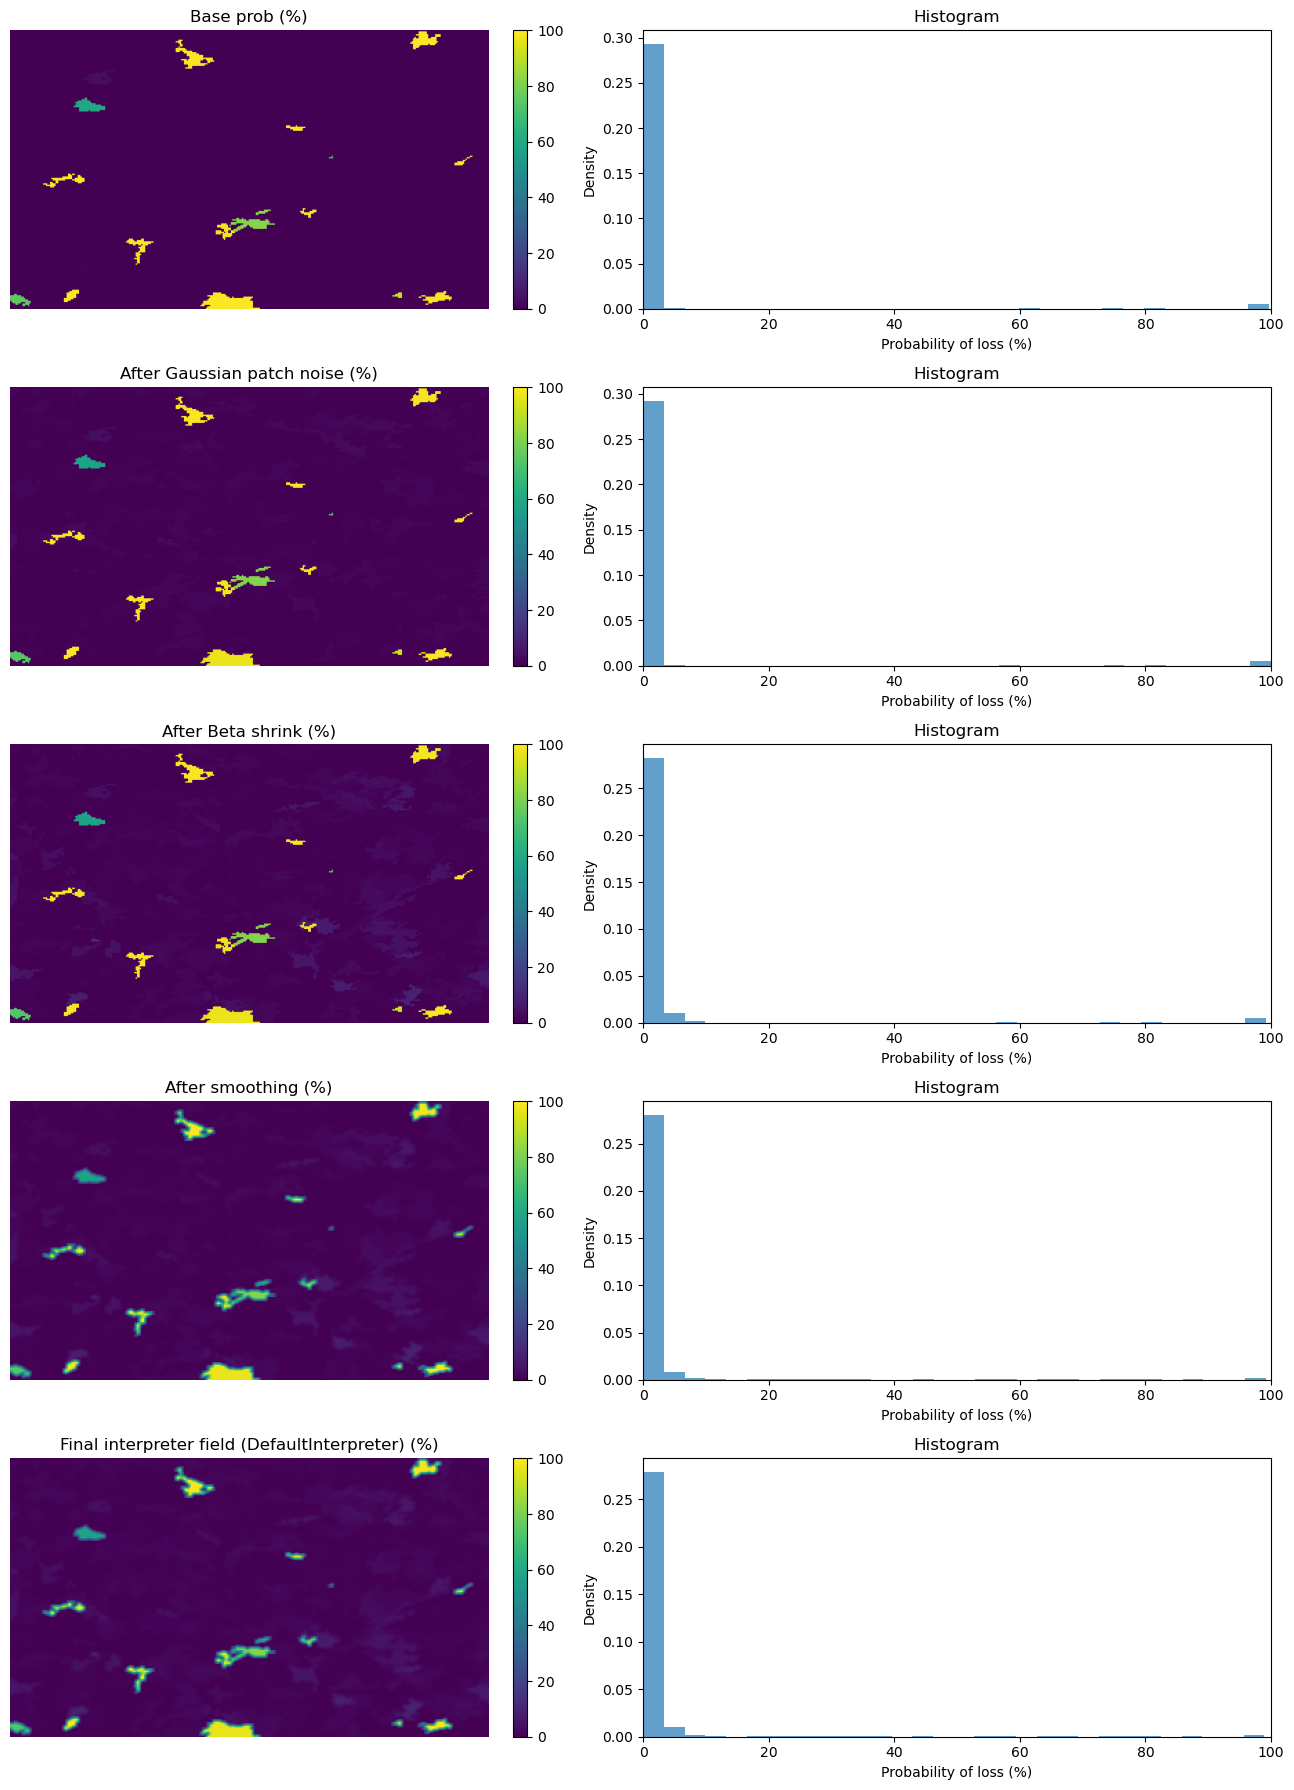

In [13]:
#  now plot the interpreter values
#  Grab a single stack. 

this = train_collection.stacks[0]
print(this.sensor_fields)
print(this.interpreter_field)

this.interpreter_field.plot_pipeline()
# this.sensor_fields['Landsat_OLI'].plot_pipeline()

experiment_config = {
    "landscape_stack_config":  landscape_stack_config, 
    "experiment_config": train_experiment_config
}

export_with_metadata(experiment_config, notes="Basic defaults")


